Imports


In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

Leemos el dataset limpio


In [79]:
df = pd.read_csv("data/cleaned_online_retail.csv")
df.shape

(362373, 8)

## Feature Engineering


Una columna que nos sería de mucha utilidad ahora mismo sería el total de cada registro.

Esto es "Quantity" multiplicado por "UnitPrice", que representaría el total de esa línea de venta. Siendo que la línea de venta pertenece a una factura.


In [80]:
df["Total"] = df["Quantity"] * df["UnitPrice"]
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


Lo que vamos a hacer será agrupar por "CustomerID" nuestros registros, y en el proceso vamos a crear nuevos campos.


Estos campos se corresponden al análisis RFM, y son:

- Recency: Cuánto tiempo pasó desde la última compra del cliente.
- Frequency: Cuántas compras realizó el cliente.
- Monetary: la cantidad de dinero gastado por el cliente.


"Recency" no podremos hacerlo en el mismo groupby, así que de momento nos contentamos con ir tomando el "LastInvoiceDate", que no es más que la última fecha de una factura asociada a ese cliente. Sería como la fecha de su última compra.


In [81]:
aggregated_df = df.groupby(by="CustomerID", as_index=False).agg(
    Monetary=("Total", "sum"),
    Frequency=("InvoiceNo", "nunique"),
    LastInvoiceDate=("InvoiceDate", "max"),
)

aggregated_df.head(3)

,CustomerID,Monetary,Frequency,LastInvoiceDate
0,12347.0,4310.00,7,2011-12-07 15:52:00
1,12348.0,1437.24,4,2011-09-25 13:13:00
2,12349.0,1457.55,1,2011-11-21 09:51:00


Como dice la descripción de este dataset, las transacciones van desde el 01/12/2010 hasta el 09/12/2011.


Si es que no borramos los últimos registros en nuestro proceso de limpieza, la mayor "LastInvoiceDate" debería estar cerca del 09/12/2011.


In [82]:
max_last_invoice_date = aggregated_df["LastInvoiceDate"].max()
max_last_invoice_date

'2011-12-09 12:50:00'

Efectivamente.


Cuando hablamos de "Recency", nos referimos al tiempo que transcurrió desde la última compra del cliente.


Este cálculo que hacemos del máximo valor de "LastInvoiceDate" es porque vamos a usar esa fecha como nuestro PRESENTE.


Esto lo hacemos para evitar distorsionar los resultados. Ya que si usamos la fecha presente, todos los clientes tendrían, por lo menos, una inactividad de 14 años.


In [83]:
# Convertimos a datetime
aggregated_df["LastInvoiceDate"] = pd.to_datetime(aggregated_df["LastInvoiceDate"])
max_last_invoice_date = pd.to_datetime(max_last_invoice_date)

In [84]:
aggregated_df["Recency"] = (
    max_last_invoice_date - aggregated_df["LastInvoiceDate"]
).dt.days

aggregated_df.head(3)

,CustomerID,Monetary,Frequency,LastInvoiceDate,Recency
0,12347.0,4310.00,7,2011-12-07 15:52:00,1
1,12348.0,1437.24,4,2011-09-25 13:13:00,74
2,12349.0,1457.55,1,2011-11-21 09:51:00,18


Ahora que ya tenemos calculadas nuestras variables RFM, vamos a visualizarlas.


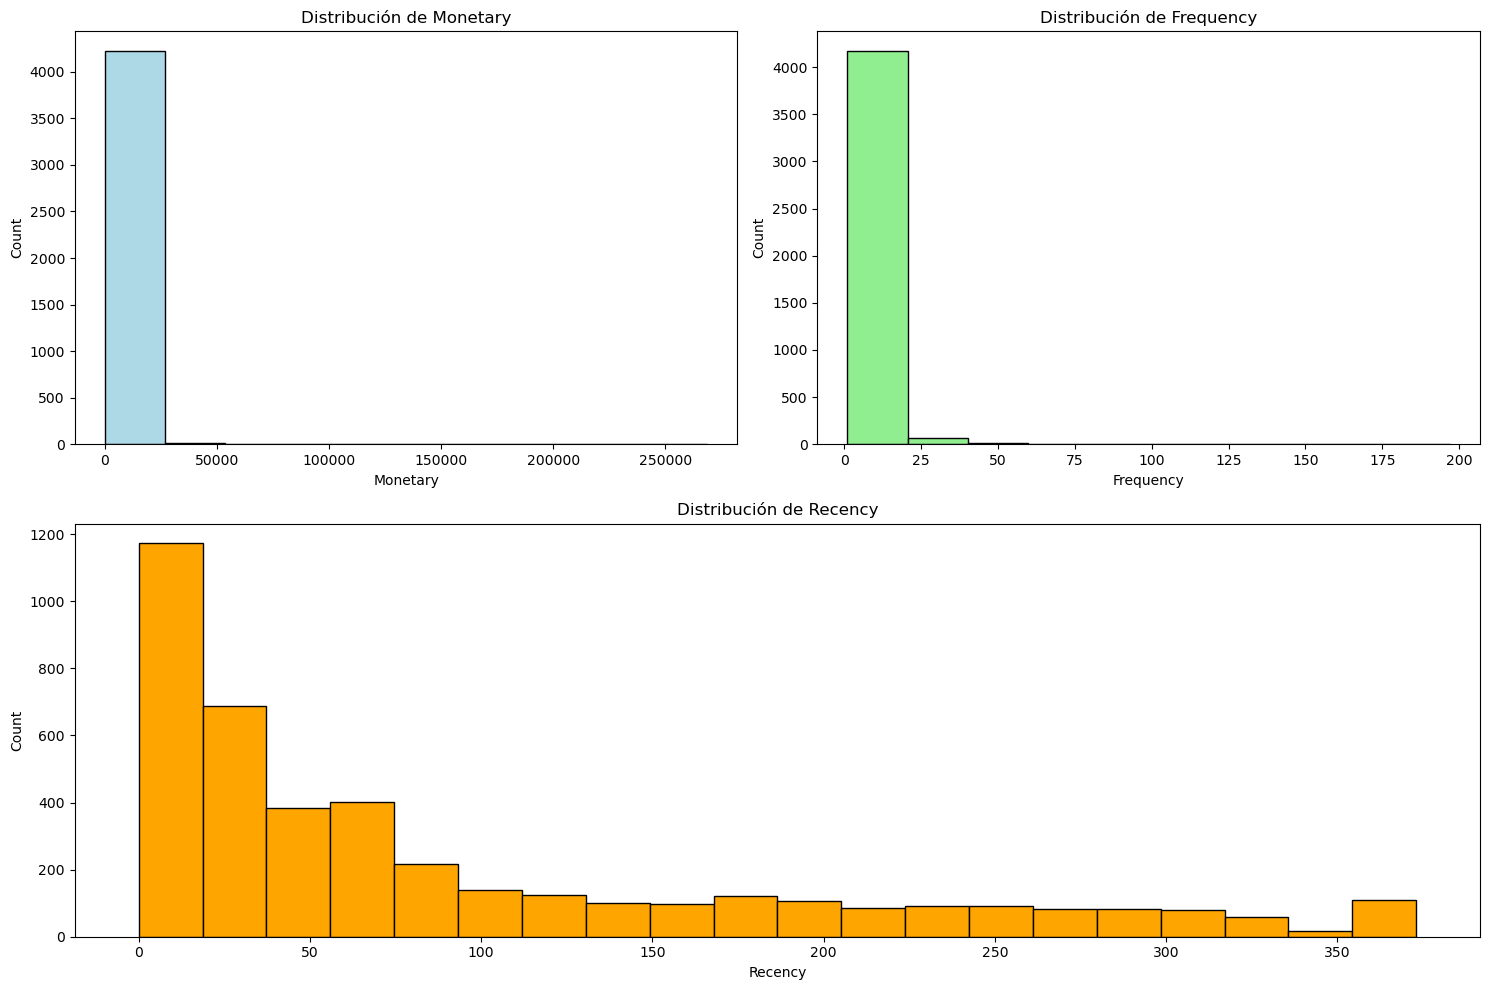

In [85]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.hist(aggregated_df["Monetary"], bins=10, color="lightblue", edgecolor="black")
plt.title("Distribución de Monetary")
plt.xlabel("Monetary")
plt.ylabel("Count")

plt.subplot(2, 2, 2)
plt.hist(aggregated_df["Frequency"], bins=10, color="lightgreen", edgecolor="black")
plt.title("Distribución de Frequency")
plt.xlabel("Frequency")
plt.ylabel("Count")

plt.subplot(2, 2, (3, 4))
plt.hist(aggregated_df["Recency"], bins=20, color="orange", edgecolor="black")
plt.title("Distribución de Recency")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Observaciones


En base a los histogramas que hicimos de RFM, podemos observar lo siguiente:


- Monetary: Sesgado a la derecha. La mayor parte de los clientes gasta una modesta cantidad de dinero. Se apilan en el primer "bin", cerca de cero, mientras que existe una cola larga que llega a valores superiores a $250mil


- Frequency: Similar a "Monetary". La gran mayoría compra entre 0 y 25 veces. Valores mayores de frecuencia empiezan a tener mucho menos aparición. Hasta llegar a casos excepcionales como son alrededor de 200 de "Frequency".


- Recency: Se observa un pico al inicio (clientes que compraron recientemente) y una cola extendida hasta poco más de 350 días.


Todo esto parece tener un comportamiento "Long-tail", que es una distribución donde hay pocos elementos muy frecuentes o valiosos, y muchos elementos poco frecuentes.


En nuestro caso de clientes de una online retail, sería algo así como:


> Hay pocos clientes que compran mucho y seguido, pero muchos que compran poco y rara vez


---


Así como hicimos en nuestro EDA, vamos a visualizar boxplots, pero de las nuevas variables RFM.


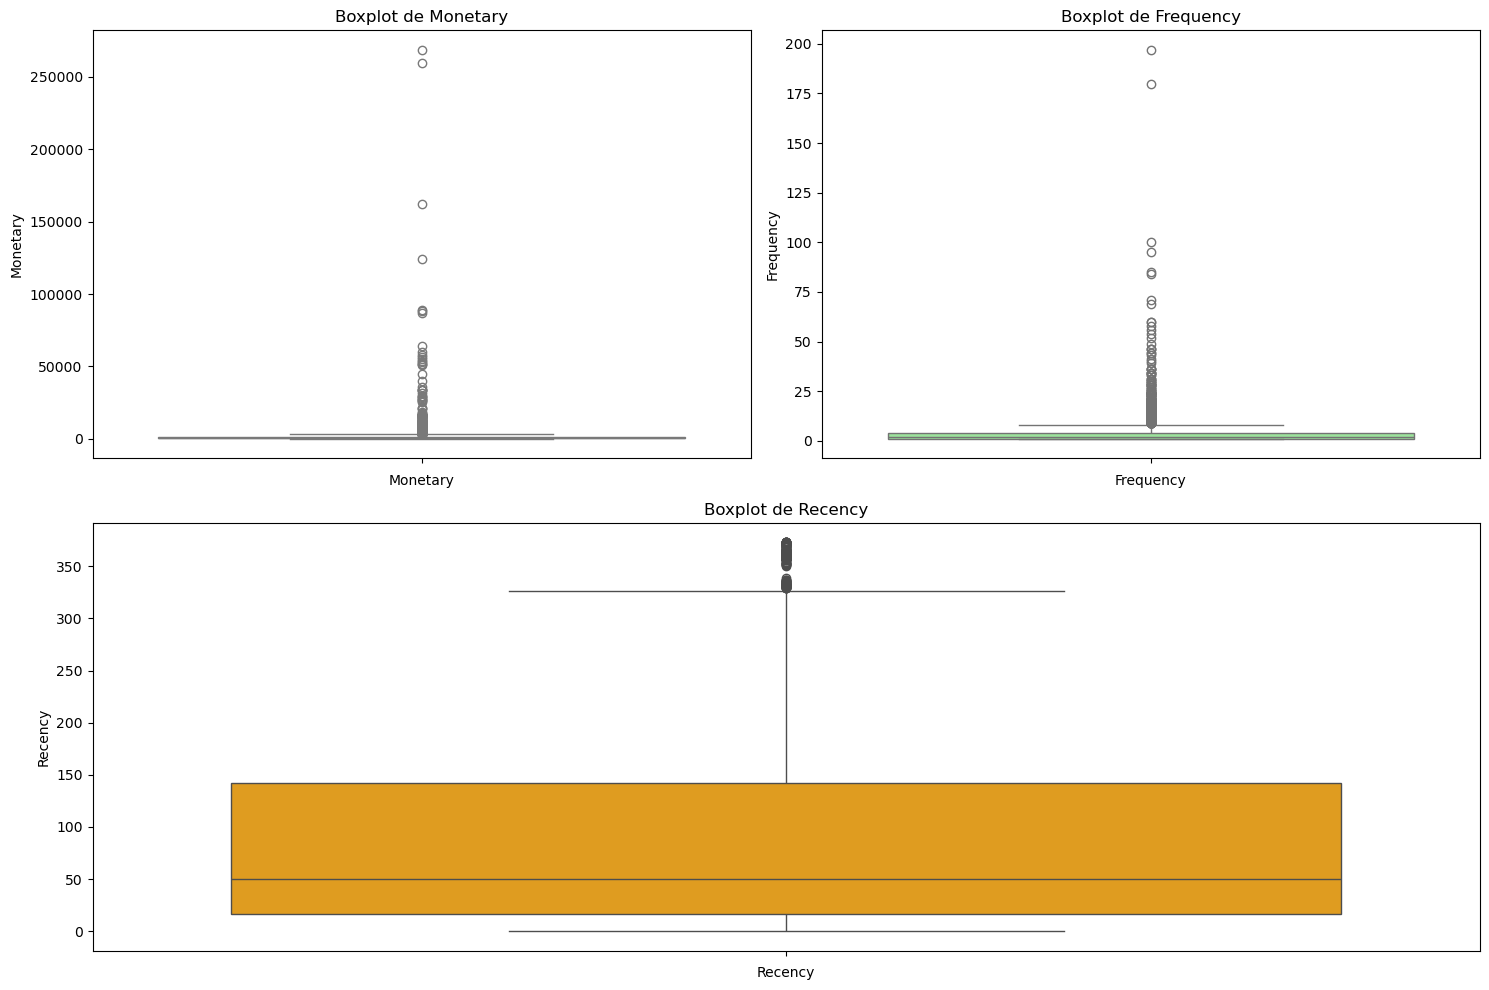

In [86]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(data=aggregated_df["Monetary"], color="lightblue")
plt.title("Boxplot de Monetary")
plt.xlabel("Monetary")

plt.subplot(2, 2, 2)
sns.boxplot(data=aggregated_df["Frequency"], color="lightgreen")
plt.title("Boxplot de Frequency")
plt.xlabel("Frequency")

plt.subplot(2, 2, (3, 4))
sns.boxplot(data=aggregated_df["Recency"], color="orange")
plt.title("Boxplot de Recency")
plt.xlabel("Recency")

plt.tight_layout()
plt.show()

### Observaciones


Las tres variables RFM muestran una cola larga. Especialmente "Monetary" y "Recency".


- "Monetary" y "Frequency": la gran mayoría de los clientes gasta poco y compra entre 1 a 5 veces. Solo unos pocos llegan a montos y a frecuencias más altas.


- "Recency": hay muchos compradores recientes (valores cercanos a 0 días), y una cola que se estira hasta aproximadamente un año (estas serían cuentas más inactivas).


Estos boxplots dejan en evidencia eso. El rectángulo, que representa entre el percentil 25 y el percentil 75, está muy baco en "Monetary" y en "Frequency", y los bigotes son cortos y seguidos por una nube de puntos aislados que vendrían siendo outliers.


Esto nos confirma que esos pocos clientes extremos podrían sesgar promedios y desviar los algoritmos de clustering que usemos más adelante.


---


Lo que vamos a hacer será separar estos outliers y analizarlos por separado. Porque si bien pueden perjudicar los algoritmos de clustering que apliquemos, descartarlos por completo no tendría sentido ya que son clientes muy valiosos para el ecommerce. Estamos hablando de mucho "Monetary" y mucho "Frequency".


Lo que vamos a hacer será calcular los puntos que dividen en cuatro cuartiles la distribución de "Monetary" y de "Frequency" y a partir de eso definiremos el rango intercuartílico (IQR). Con q1 y q3, establecemos un umbral de 1,5 veces el IQR por encima y por debajo según la regla de Tukey.


La idea es quedarnos con aquellos clientes que superan ese umbral. Para nuestro caso en particular nos importan los que están por encima. No por debajo.


In [87]:
# Calculamos el IQR para "Monetary"
monetary_q1 = aggregated_df["Monetary"].quantile(0.25)
monetary_q3 = aggregated_df["Monetary"].quantile(0.75)
monetary_iqr = monetary_q3 - monetary_q1
monetary_outlier_threshold = monetary_q3 + 1.5 * monetary_iqr

In [88]:
# Separamos los outliers por encima del IQR de "Monetary"
monetary_outliers = aggregated_df[
    aggregated_df["Monetary"] > monetary_outlier_threshold
]
monetary_outliers.describe()

,CustomerID,Monetary,Frequency,LastInvoiceDate,Recency
count,422.000000,422.000000,422.000000,422,422.000000
mean,15029.744076,11007.871801,15.800948,2011-11-15 23:28:08.104265216,23.085308
min,12347.000000,3346.280000,1.000000,2010-12-02 15:27:00,0.000000
25%,13320.250000,4057.837500,7.000000,2011-11-15 14:16:45,3.000000
50%,15014.000000,5237.780000,11.500000,2011-11-29 14:11:00,9.000000
75%,16654.250000,8684.860000,18.000000,2011-12-06 12:22:15,23.000000
max,18251.000000,268748.960000,197.000000,2011-12-09 12:49:00,371.000000
std,1801.781812,22964.755121,17.717316,NaN,41.677273


In [89]:
# Calculamos el IQR para "Frequency"
frequency_q1 = aggregated_df["Frequency"].quantile(0.25)
frequency_q3 = aggregated_df["Frequency"].quantile(0.75)
frequency_iqr = frequency_q3 - frequency_q1
frequency_outlier_threshold = frequency_q3 + 1.5 * frequency_iqr

In [90]:
# Separamos los outliers por encima del IQR de "Frequency"
frequency_outliers = aggregated_df[
    aggregated_df["Frequency"] > frequency_outlier_threshold
]
frequency_outliers.describe()

,CustomerID,Monetary,Frequency,LastInvoiceDate,Recency
count,408.000000,408.000000,408.000000,408,408.000000
mean,15356.325980,10128.250098,17.882353,2011-11-22 12:48:49.411764736,16.509804
min,12362.000000,721.630000,9.000000,2010-12-02 15:27:00,0.000000
25%,13887.750000,2806.070000,10.000000,2011-11-18 10:43:00,2.000000
50%,15250.000000,4497.060000,13.000000,2011-12-01 12:19:00,8.000000
75%,16837.500000,8005.555000,19.000000,2011-12-06 17:08:45,21.000000
max,18283.000000,268748.960000,197.000000,2011-12-09 12:49:00,371.000000
std,1748.277629,23501.417599,17.150465,NaN,30.511204


Y ahora que tenemos los outliers en sus respectivos dataframes, nos armamos un nuevo dataframe que contenga los registros restantes, es decir, que no son outliers ni de "Monetary" ni de "Frequency".


In [91]:
non_outliers = aggregated_df[
    (~aggregated_df.index.isin(monetary_outliers.index))
    & (~aggregated_df.index.isin(frequency_outliers.index))
]
non_outliers.describe()

,CustomerID,Monetary,Frequency,LastInvoiceDate,Recency
count,3706.000000,3706.000000,3706.000000,3706,3706.000000
mean,15327.240421,765.011431,2.485159,2011-08-29 07:32:35.909336320,101.703994
min,12348.000000,0.850000,1.000000,2010-12-01 09:53:00,0.000000
25%,13856.500000,256.637500,1.000000,2011-06-27 12:15:15,22.000000
50%,15340.000000,522.725000,2.000000,2011-10-10 13:29:00,59.000000
75%,16802.500000,1054.715000,3.000000,2011-11-16 16:47:30,164.750000
max,18287.000000,3313.790000,8.000000,2011-12-09 12:50:00,373.000000
std,1707.937590,694.612444,1.764218,NaN,102.419534


Con todo esto, visualizamos nuevamente los boxplot de las variables de RFM.


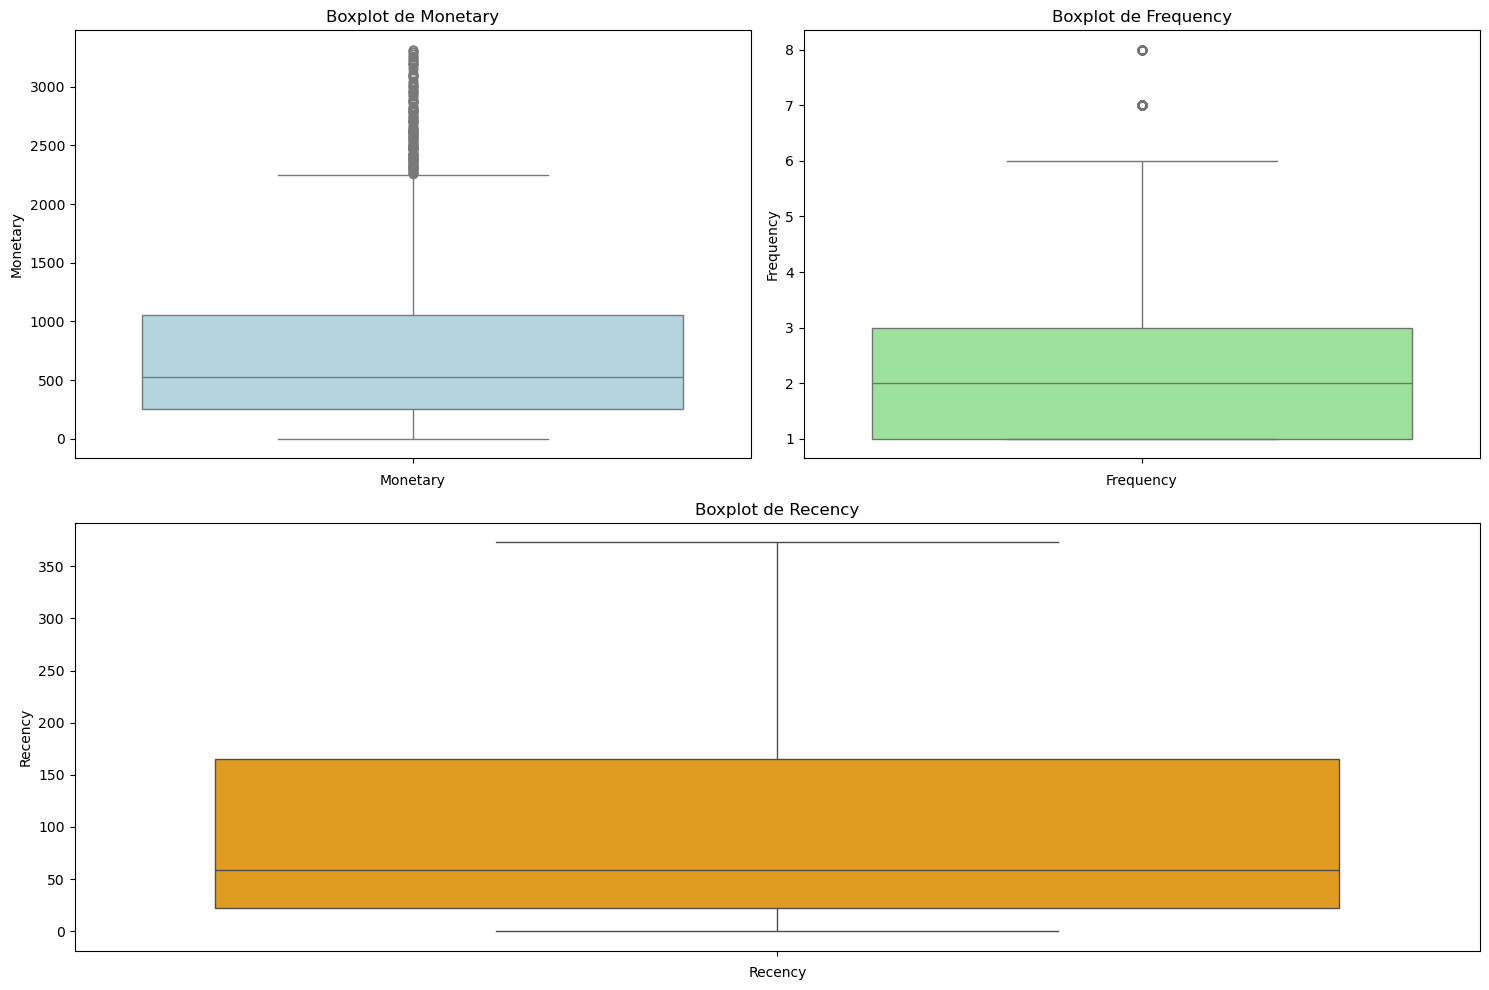

In [92]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(data=non_outliers["Monetary"], color="lightblue")
plt.title("Boxplot de Monetary")
plt.xlabel("Monetary")

plt.subplot(2, 2, 2)
sns.boxplot(data=non_outliers["Frequency"], color="lightgreen")
plt.title("Boxplot de Frequency")
plt.xlabel("Frequency")

plt.subplot(2, 2, (3, 4))
sns.boxplot(data=non_outliers["Recency"], color="orange")
plt.title("Boxplot de Recency")
plt.xlabel("Recency")

plt.tight_layout()
plt.show()

La distribución mejoró para "Monetary", y para "Frequency", de forma directa. Además de que indirectamente, al borrar outliers de esas variables, se fueron también los outliers presentes en "Recency".


- "Monetary": El IQR va de aproximadamente 300$ hasta un poco más de 1000$, con una mediana cerca de 500$, y quedan unos cuantos outliers por encima de aproximadamente 2300$.

- "Frequency": El IQR va de 1 a 3 compras por cliente, con mediana en 2, y apenas sobreviven algunos outliers hasta 8 compras por cliente.

- "Recency": El IQR va entre aproximadamente 20 y 160 días desde la última compra, con una mediana cerca de los 60 días. La cola larga que llega casi a 360 días refleja clientes más inactivos. No se observan outliers en esta variable.


In [93]:
non_outliers.columns

Index(['CustomerID', 'Monetary', 'Frequency', 'LastInvoiceDate', 'Recency'], dtype='object')

Algo interesante del análisis RFM es que al tratarse de 3 variables, podemos intentar visualizarlas en un espacio tridimensional.


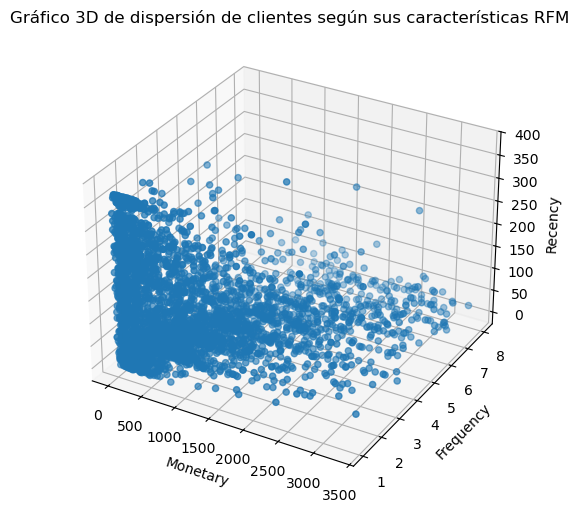

In [94]:
fig = plt.figure(figsize=(6, 16))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(
    non_outliers["Monetary"],
    non_outliers["Frequency"],
    non_outliers["Recency"],
)

ax.set_xlabel("Monetary")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")

ax.set_title("Gráfico 3D de dispersión de clientes según sus características RFM")

plt.show()

### Observaciones


- Cada variable maneja una escala diferente. "Frequency" va de 1 al 8. "Recency" va de 0 a 400. "Monetary" va de 0 a 3500.


- Esta diferencia de escala puede darnos problemas al provocar que en algunos algoritmos de Clustering, una variable **domine** a la otra.


### Escalado estándar


El escalado estándar que nos ofrece sklearn en la clase `StandardScaler` transforma cada variable para que tenga media (mean) igual a 0, y desviación estándar (std) igual a 1, logrando que todas las variables estén en la misma escala.


Así evitamos que variables con un rango amplio como "Monetary" tiren de la distancia euclídea y deje en segundo plano a las otras dos "Frequency" y "Recency", garantizando que cada una aporte por igual al cálculo.


Su fórmula es la siguiente:


$$
z = \frac{x - \mu}{\sigma}
$$

Donde:

- $z$ es el valor estandarizado,
- $x$ es el valor original,
- $\mu$ es la media de la feature,
- $\sigma$ es la desviación estandar de la feature.


In [95]:
# Instanciamos el escalador
scaler = StandardScaler()

In [97]:
# Escalamos las variables "Monetary", "Frequency" y "Recency"
scaled_data = scaler.fit_transform(non_outliers[["Monetary", "Frequency", "Recency"]])

In [98]:
# Volvemos a crear un DataFrame con los datos escalados
scaled_df = pd.DataFrame(
    scaled_data, columns=["Monetary", "Frequency", "Recency"], index=non_outliers.index
)
scaled_df.describe()

,Monetary,Frequency,Recency
count,3.706000e+03,3.706000e+03,3.706000e+03
mean,6.135285e-17,7.189788e-17,4.505600e-17
std,1.000135e+00,1.000135e+00,1.000135e+00
min,-1.100275e+00,-8.419365e-01,-9.931476e-01
25%,-7.319802e-01,-8.419365e-01,-7.783159e-01
50%,-3.488551e-01,-2.750367e-01,-4.170079e-01
75%,4.171285e-01,2.918632e-01,6.156493e-01
max,3.669849e+00,3.126362e+00,2.649227e+00


Ahora podemos volver a graficar las variables RFM y veremos que se encuentran en la misma escala.


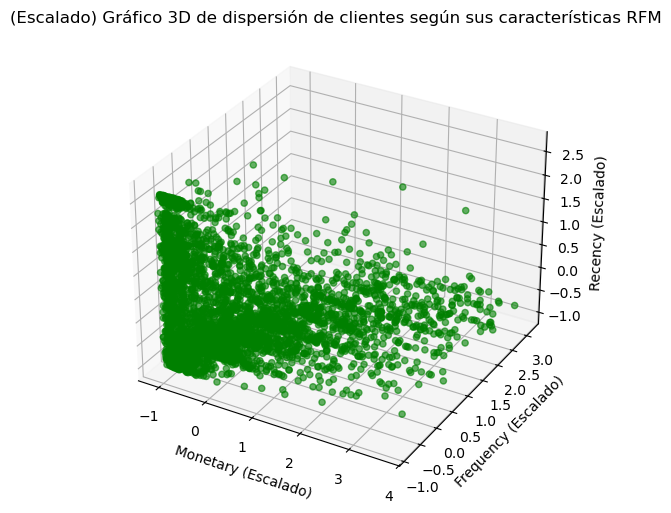

In [101]:
fig = plt.figure(figsize=(6, 16))

ax = fig.add_subplot(projection="3d")

scatter = ax.scatter(
    scaled_df["Monetary"],
    scaled_df["Frequency"],
    scaled_df["Recency"],
    c="green",
    alpha=0.6,
)

ax.set_xlabel("Monetary (Escalado)")
ax.set_ylabel("Frequency (Escalado)")
ax.set_zlabel("Recency (Escalado)")

ax.set_title(
    "(Escalado) Gráfico 3D de dispersión de clientes según sus características RFM"
)

plt.show()

Podemos visualizar de otras maneras el resultado del proceso de escalado.


In [103]:
print(scaled_df.describe().loc[["mean", "std"]])

          Monetary     Frequency       Recency
mean  6.135285e-17  7.189788e-17  4.505600e-17
std   1.000135e+00  1.000135e+00  1.000135e+00


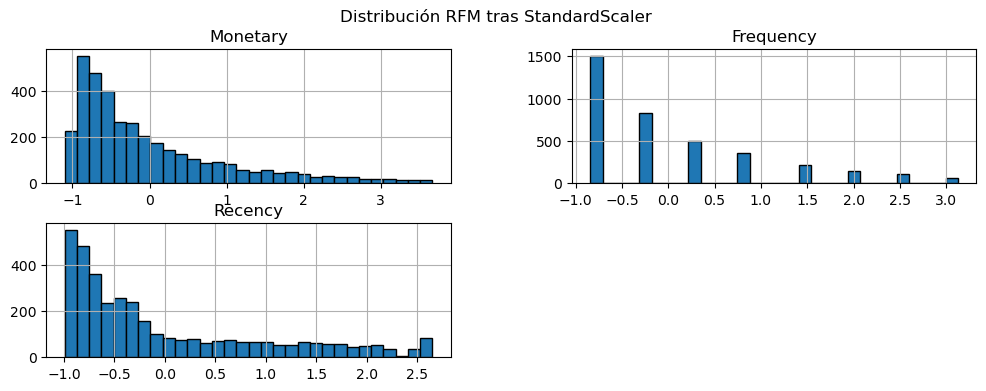

In [104]:
scaled_df.hist(bins=30, figsize=(12, 4), edgecolor="black")
plt.suptitle("Distribución RFM tras StandardScaler")
plt.show()

In [105]:
# Guardamos el dataframe escalado
scaled_df.to_csv("data/scaled_online_retail.csv", index=False)

In [106]:
# Guardamos los dataframes de outliers
monetary_outliers.to_csv("data/monetary_outliers.csv", index=False)
frequency_outliers.to_csv("data/frequency_outliers.csv", index=False)
non_outliers.to_csv("data/non_outliers.csv", index=False)